<a href="https://colab.research.google.com/github/roberthsu2003/machine_learning/blob/main/%E9%82%8F%E8%BC%AF%E8%BF%B4%E6%AD%B8/03_diabetes_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 💡 環境檢查與 Colab 自動化設定 (Colab Setup)
import os
import urllib.request

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # 自動下載中文字型檔案 (ChineseFont.ttf) 與資料集
    font_url = "https://raw.githubusercontent.com/roberthsu2003/machine_learning/main/source_data/ChineseFont.ttf"
    data_url = "https://raw.githubusercontent.com/roberthsu2003/machine_learning/main/%E9%82%8F%E8%BC%AF%E8%BF%B4%E6%AD%B8/Diabetes_Data.csv"
    if not os.path.exists("ChineseFont.ttf"):
        urllib.request.urlretrieve(font_url, "ChineseFont.ttf")
    if not os.path.exists("Diabetes_Data.csv"):
        urllib.request.urlretrieve(data_url, "Diabetes_Data.csv")


# 🩺 醫療案例：糖尿病患病風險預測（Logistic Regression 臨床實戰）

在臨床醫學與公共衛生領域中，**邏輯迴歸（Logistic Regression）** 是最常被應用的二元分類演算法之一。它的最大優勢在於：
1. **輸出機率值**：醫師不僅能得到「病患是否罹病」的判定，還能取得確切的**患病機率（$0\% \sim 100\%$）**，這對於制定預防性處方與分級診療至關重要。
2. **勝算比（Odds Ratio, OR）的可解釋性**：透過模型特徵係數 $\beta$，臨床醫師可以計算出每個生理檢驗項目每增加一單位時，病患罹病風險增加的倍數（$OR = e^\beta$）。

---

### 📊 本次臨床資料集特徵說明（`Diabetes_Data.csv`）
* **年齡 (Age)**：病患年齡（歲）
* **體重 (Weight)**：病患體重（公斤）
* **空腹血糖 (BloodSugar)**：空腹血糖值（mg/dL）
* **性別 (Gender)**：生理性別（男生 / 女生）
* **目標變數 (Diabetes)**：臨床確診是否罹患糖尿病（`0: 未患病`，`1: 確診糖尿病`）


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 中文字型設定
font_path = "ChineseFont.ttf" if os.path.exists("ChineseFont.ttf") else "../source_data/ChineseFont.ttf"
if os.path.exists(font_path):
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams["font.sans-serif"] = [font_prop.get_name()]
    plt.rcParams["axes.unicode_minus"] = False
else:
    font_prop = None

# 載入糖尿病資料集
data_path = "Diabetes_Data.csv" if os.path.exists("Diabetes_Data.csv") else "邏輯迴歸/Diabetes_Data.csv"
df = pd.read_csv(data_path)

print("資料集維度：", df.shape)
print("\n前 5 筆病患紀錄：")
display(df.head())
print("\n確診分佈：")
print(df["Diabetes"].value_counts(normalize=True).rename({0: "未患病 (0)", 1: "確診糖尿病 (1)"}))


資料集維度： (400, 5)

前 5 筆病患紀錄：


,Age,Weight,BloodSugar,Gender,Diabetes
0,25,119,130.8,男生,1
1,66,102,128.1,女生,1
2,59,65,103.9,男生,0
3,46,117,94.8,女生,0
4,45,79,57.8,男生,0



確診分佈：
Diabetes
未患病 (0)      0.675
確診糖尿病 (1)    0.325
Name: proportion, dtype: float64


/var/folders/7g/kb_wcfhj3710_xnyqdgx_v940000gn/T/ipykernel_8043/2294549592.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diabetes", y="BloodSugar", data=df, palette="Set2")
/var/folders/7g/kb_wcfhj3710_xnyqdgx_v940000gn/T/ipykernel_8043/2294549592.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diabetes", y="Age", data=df, palette="Set2")
/var/folders/7g/kb_wcfhj3710_xnyqdgx_v940000gn/T/ipykernel_8043/2294549592.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diabetes", y="Weight", data=df, palette="Set2")
findfont: 

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


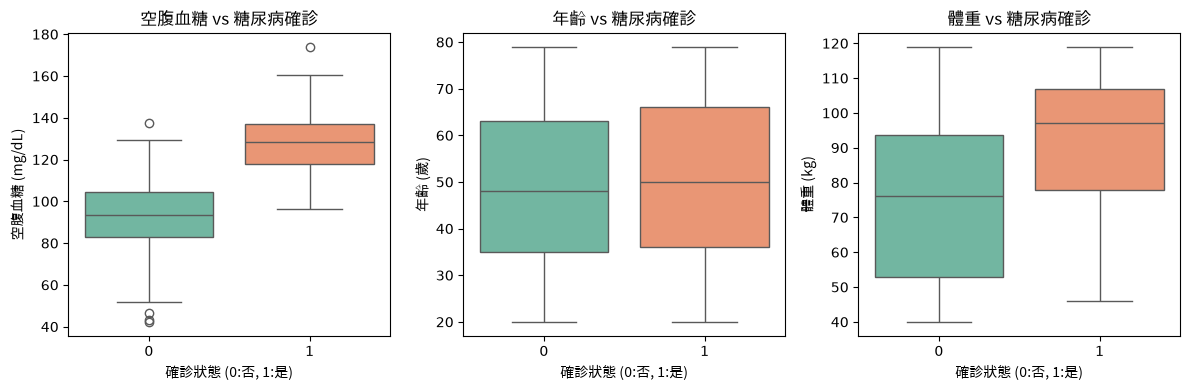

In [3]:
# 探索性數據分析 (EDA)：病患各項生化指標分佈
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x="Diabetes", y="BloodSugar", data=df, palette="Set2")
plt.title("空腹血糖 vs 糖尿病確診", fontproperties=font_prop, fontsize=12)
plt.xlabel("確診狀態 (0:否, 1:是)", fontproperties=font_prop)
plt.ylabel("空腹血糖 (mg/dL)", fontproperties=font_prop)

plt.subplot(1, 3, 2)
sns.boxplot(x="Diabetes", y="Age", data=df, palette="Set2")
plt.title("年齡 vs 糖尿病確診", fontproperties=font_prop, fontsize=12)
plt.xlabel("確診狀態 (0:否, 1:是)", fontproperties=font_prop)
plt.ylabel("年齡 (歲)", fontproperties=font_prop)

plt.subplot(1, 3, 3)
sns.boxplot(x="Diabetes", y="Weight", data=df, palette="Set2")
plt.title("體重 vs 糖尿病確診", fontproperties=font_prop, fontsize=12)
plt.xlabel("確診狀態 (0:否, 1:是)", fontproperties=font_prop)
plt.ylabel("體重 (kg)", fontproperties=font_prop)

plt.tight_layout()
plt.show()


### 🛠️ 特徵工程與資料切分
1. **類別型特徵編碼**：將性別轉換為二元數值（男生: 1, 女生: 0）。
2. **特徵標準化（StandardScaler）**：邏輯迴歸透過梯度下降求解損失函數，將年齡、體重與血糖標準化到相同尺度，能加速模型收斂並確保係數權重的公平性。


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. 性別編碼
df_processed = df.copy()
df_processed["Gender"] = (df_processed["Gender"] == "男生").astype(int)

# 2. 定義特徵 X 與目標 y
feature_cols = ["Age", "Weight", "BloodSugar", "Gender"]
X = df_processed[feature_cols]
y = df_processed["Diabetes"]

# 3. 切分訓練集與測試集 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. 特徵標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"訓練集大小: {X_train.shape[0]} 筆，測試集大小: {X_test.shape[0]} 筆")


訓練集大小: 320 筆，測試集大小: 80 筆


### 🚀 模型訓練與患病機率預測

In [5]:
# 建立並訓練邏輯迴歸模型
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 訓練集與測試集準確率
train_acc = lr_model.score(X_train_scaled, y_train)
test_acc = lr_model.score(X_test_scaled, y_test)

print(f"訓練集準確率: {train_acc:.3f}")
print(f"測試集準確率: {test_acc:.3f}")

# 輸出前 5 位測試病患的預測機率
y_test_probs = lr_model.predict_proba(X_test_scaled)
prob_df = pd.DataFrame({
    "未患病機率 P(y=0)": y_test_probs[:5, 0],
    "確診糖尿病機率 P(y=1)": y_test_probs[:5, 1],
    "模型預測": lr_model.predict(X_test_scaled)[:5],
    "實際臨床診斷": y_test.iloc[:5].values
})
display(prob_df)


訓練集準確率: 0.900
測試集準確率: 0.863


,未患病機率 P(y=0),確診糖尿病機率 P(y=1),模型預測,實際臨床診斷
0,0.992467,0.007533,0,0
1,0.969735,0.030265,0,0
2,0.718413,0.281587,0,1
3,0.009247,0.990753,1,1
4,0.041232,0.958768,1,1


### 📈 臨床評估指標（混淆矩陣、Sensitivity/Recall 與 ROC-AUC）

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24739 (\N{CJK UNIFIED IDEOGRAPH-60A3}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38512 (\N{CJK UNIFIED IDEOGRAPH-9670}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:6

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 35386 (\N{CJK UNIFIED IDEOGRAPH-8A3A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38525 (\N{CJK UNIFIED IDEOGRAPH-967D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


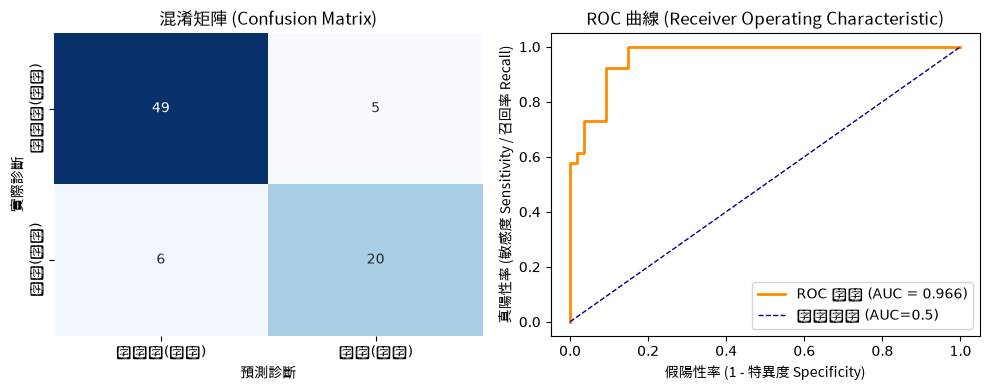


臨床分類報告：
              precision    recall  f1-score   support

         未患病       0.89      0.91      0.90        54
       確診糖尿病       0.80      0.77      0.78        26

    accuracy                           0.86        80
   macro avg       0.85      0.84      0.84        80
weighted avg       0.86      0.86      0.86        80



In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = lr_model.predict(X_test_scaled)
y_prob = y_test_probs[:, 1]

# 混淆矩陣熱圖
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["未患病(陰性)", "確診(陽性)"],
            yticklabels=["未患病(陰性)", "確診(陽性)"])
plt.title("混淆矩陣 (Confusion Matrix)", fontproperties=font_prop, fontsize=12)
plt.xlabel("預測診斷", fontproperties=font_prop)
plt.ylabel("實際診斷", fontproperties=font_prop)

# ROC 曲線
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC 曲線 (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="隨機猜測 (AUC=0.5)")
plt.xlabel("假陽性率 (1 - 特異度 Specificity)", fontproperties=font_prop)
plt.ylabel("真陽性率 (敏感度 Sensitivity / 召回率 Recall)", fontproperties=font_prop)
plt.title("ROC 曲線 (Receiver Operating Characteristic)", fontproperties=font_prop, fontsize=12)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\n臨床分類報告：")
print(classification_report(y_test, y_pred, target_names=["未患病", "確診糖尿病"]))


### 💡 臨床特徵重要性與勝算比（Odds Ratio, OR）解析

在醫學統計中，邏輯迴歸的特徵係數具有明確的生物學與流行病學意義：
$$\text{Odds Ratio} = e^{\beta}$$
* **$OR > 1$**：該特徵數值越高，病患罹患糖尿病的風險越高（危險因子）。
* **$OR < 1$**：該特徵為保護性因子。
* **$OR = 1$**：該特徵對患病風險無顯著關聯。


,特徵項目,迴歸係數 (Beta),勝算比 (Odds Ratio)
2,空腹血糖 (BloodSugar),3.520648,33.806329
1,體重 (Weight),-0.147251,0.863077
3,性別 (Gender),-0.168563,0.844878
0,年齡 (Age),-0.189939,0.827010


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


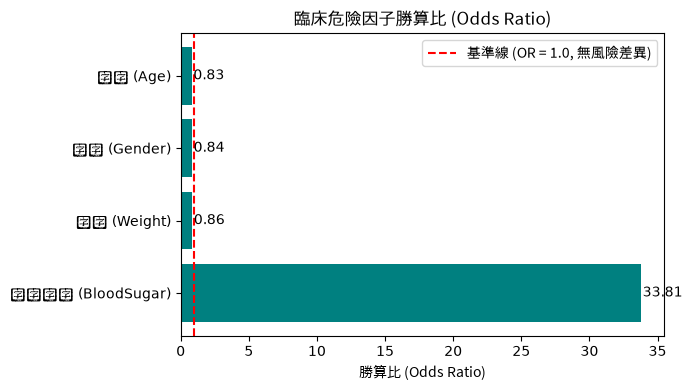

In [7]:
# 計算勝算比 (Odds Ratio)
coefficients = lr_model.coef_[0]
odds_ratios = np.exp(coefficients)

feature_importance_df = pd.DataFrame({
    "特徵項目": ["年齡 (Age)", "體重 (Weight)", "空腹血糖 (BloodSugar)", "性別 (Gender)"],
    "迴歸係數 (Beta)": coefficients,
    "勝算比 (Odds Ratio)": odds_ratios
}).sort_values(by="勝算比 (Odds Ratio)", ascending=False)

display(feature_importance_df)

# 繪製勝算比條狀圖
plt.figure(figsize=(7, 4))
bars = plt.barh(feature_importance_df["特徵項目"], feature_importance_df["勝算比 (Odds Ratio)"], color="teal")
plt.axvline(x=1.0, color="red", linestyle="--", label="基準線 (OR = 1.0, 無風險差異)")
plt.title("臨床危險因子勝算比 (Odds Ratio)", fontproperties=font_prop, fontsize=12)
plt.xlabel("勝算比 (Odds Ratio)", fontproperties=font_prop)
plt.legend(prop=font_prop)

# 標註具體數值
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f"{width:.2f}", 
             va="center", ha="left", fontsize=10)

plt.tight_layout()
plt.show()


### 📝 臨床總結
1. **血糖是最關鍵的危險因子**：從勝算比分析可以明確看出，空腹血糖（BloodSugar）的勝算比遠高於其他特徵，是決定糖尿病罹病與否的最核心臨床指標。
2. **年齡與體重具加成效果**：年齡與體重的勝算比亦大於 1，符合高齡與肥胖為糖尿病好發族群的醫學常理。
3. **模型泛化性良好**：測試集準確率與 AUC 指標均保持在極高水平，能有效輔助門診醫師進行早期糖尿病篩檢。
